## 2장 2강: 경사하강법, 옵티마이저 및 데이터 분할

In [1]:
# 다향 회귀 = 3개의 feature를 가지고 linear regression 실습
import sklearn
import pandas as pd
sklearn.set_config(display='text') # 윈도우 한글 인코딩 오류 방지


df = pd.read_csv("usa_housing.csv")

df.head()


,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
0,221958,1,1.9,4827,1979,2,1.45,82240,48.60,5
1,771155,2,2.0,1035,1987,2,1.75,74315,92.03,9
2,231932,1,3.0,2769,1982,1,1.46,79249,52.08,3
3,465838,3,3.3,2708,1907,3,1.62,80587,61.65,1
4,359178,4,3.4,1175,1994,2,0.74,20756,15.66,4


In [2]:
X = df[['SquareFeet', 'CrimeRate', 'SchoolRating']] # feature 학습 특성, 독립변수 - 2차원 DataFrame, 3가지 특성 뽑기
y = df['Price'] # label, 종속변수(X에 따라서 영향을 받으므로), Series(1 column)

X.shape, y.shape # 300개 데이터, 3개의 column(feature)



((300, 3), (300,))

In [3]:
from sklearn.linear_model import LinearRegression

model = LinearRegression() 
model.fit(X, y) # 모델 학습시키기



LinearRegression()

In [4]:
# 모델이 학습한 가중치와 절편
print("가중치:", model.coef_) # w(weight). 가중치는 feature 개수와 동일하게 만들어짐.
print("절편:", model.intercept_) # b(bias)

# y = 17x1 + 165x2 + 2753x3 + 446703 (집값 = 면적x1 + 범죄율x2 + 학군x3 + 절편(기본값)) 
# --> 다향 회귀

가중치: [  17.64218384  165.54335017 2753.89459814]
절편: 446703.79143559677


In [5]:
y_pred = model.predict(X) # y hat 계산시 .predict(X)

y_pred[:10] 

array([553677.4926239 , 504983.45760631, 512438.17995057, 507438.46740142,
       481041.34469987, 548602.92327148, 520154.49162671, 503931.32583249,
       521323.66394383, 535128.29765563])

## 특성 스케일링 (Feature Scaling)

집값을 예측할 때 면적, 범죄율, 학군처럼 여러 feature를 사용할 수 있다.

하지만 각 feature는 단위와 값의 범위가 다르다.

- 학군 점수: 1 ~ 5점
- 범죄율: 0 ~ 100
- 면적: 10 ~ 1,000㎡

값의 범위가 큰 feature는 학습 과정에서 가중치 업데이트와 거리 계산에 더 큰 영향을 줄 수 있다.  
이는 해당 feature가 실제로 더 중요해서가 아니라, **숫자의 단위가 더 크기 때문**일 수 있다.

따라서 feature의 단위를 비슷한 기준으로 맞추는 **특성 스케일링**이 필요하다.

> 스케일링은 모든 feature의 중요도를 같게 만드는 작업이 아니다.  
> 숫자 단위 때문에 특정 feature가 부당하게 큰 영향을 갖는 것을 막고,  
> 실제 중요도는 학습 과정에서 가중치($w$)가 결정하게 한다.

---

### 1. Min-Max Scaling

각 값을 최소값과 최대값을 기준으로 보통 $0 \sim 1$ 범위로 변환한다.

$$
x_{\text{new}}
=
\frac{x - x_{\min}}
{x_{\max} - x_{\min}}
$$

- 장점: 값의 범위가 명확하게 $0 \sim 1$로 통일된다.
- 주의: 이상치가 있으면 최소값·최대값이 크게 변하여 다른 값들이 한쪽에 몰릴 수 있다.

---

### 2. Z-score Standardization (StandardScaler)

각 feature의 평균을 $0$, 표준편차를 $1$이 되도록 변환한다.

$$
z
=
\frac{x - \mu}{\sigma}
$$

- $\mu$: 해당 feature의 평균
- $\sigma$: 해당 feature의 표준편차

변환 후 값의 의미는 평균으로부터 몇 표준편차만큼 떨어져 있는지를 나타낸다.

- 장점: feature마다 평균과 스케일을 통일해 모델이 안정적으로 학습하도록 돕는다.
- 주의: 평균과 표준편차를 이용하므로 이상치의 영향을 받을 수 있다.

---

## 핵심 정리

스케일링 전:

```text
면적: 10 ~ 1,000
범죄율: 0 ~ 100
학군: 1 ~ 5
```

스케일링 후:
```
모든 feature를 비슷한 기준으로 변환
→ 숫자 단위 자체가 모델에 미치는 불공정한 영향을 줄임
→ 면적·범죄율·학군 중 실제로 중요한 feature는
  학습 과정에서 더 적절한 가중치(w)를 학습하게 됨
```

각각의 데이터마다 숫자가 다름
(학군 1단위, 범죄율 10단위, 면적 1000단위 -> 다 집값에 영향을 많이 끼치는 요인들임에도 불구하고, 
숫자단위가 크면 집값에 영향을 더 많이 끼치고, 작으면 영향을 적게 미치는 결과가 나올 수 있음 -> 따라서 각 데이터를 동일한 기준으로 맞추어 주어야 함)

```
수치가 커지면 더 큰 영향을 줌 (현재 학군 1단위, 범죄율 10단위, 면적은 1000단위로 입력된 상태)
but 면적, 범죄율, 학군 모두 집값에 중요한 요인임.
therefore 기준을 통일해야 함.
방법:
    - 최소값-최대값을 이용한 (Min Max Scaler) : 값에 상관없이 숫자를 0 ~ 1로 압축
    - 표준점수 (Z-Score): 평균을 0으로 맞추고 표준편차를 1로 조정해줌(분산을 작게 만들어줌)
```

## 정규화 (특징 구분 중요)
- L2규제, L1규제와 함께 정규화로 불리나 목적이 다름
### Min-Max Scaling

- 값을 $0 \sim 1$ 사이로 압축합니다.

$$
x_{\text{new}} =
\frac{x - x_{\min}}
{x_{\max} - x_{\min}}
$$

### Z-score Standardization (StandardScaler)

- 평균을 $0$, 표준편차를 $1$로 조정하여 상대적 크기로 수치를 통일화
- 학습할때 경중이 훨씬 더 잘 반영됨

$$
x_{\text{new}} =
\frac{x - \mu}{\sigma}
$$

- $\mu$: 평균
- $\sigma$: 표준편차

In [6]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler # 3개의 feature를 통일된 기준으로 바꾸기 위한 함수를 import

# MinMaxScaler
min_max_scaler = MinMaxScaler()
min_max_scaler.fit(X.values) # 준비작업(기준을 만든다)

X_scaled1 = min_max_scaler.transform(X.values) # 변환 (0~1 사이로)

X_scaled1[:10]


array([[0.95910512, 0.48643489, 0.5       ],
       [0.04690883, 0.92282958, 1.        ],
       [0.46403656, 0.52140273, 0.25      ],
       [0.44936252, 0.61756431, 0.        ],
       [0.08058696, 0.15544614, 0.375     ],
       [0.83954775, 0.04200161, 1.        ],
       [0.62424826, 0.10942524, 0.375     ],
       [0.36805389, 0.59947749, 0.125     ],
       [0.6062064 , 0.09354904, 0.5       ],
       [0.80611018, 0.37590434, 0.25      ]])

In [7]:
# StandardScaler
ss = StandardScaler()
ss.fit(X.values) # 변환 준비작업

X_scaled2 = ss.transform(X.values) # 표준점수로 변환

X_scaled2[:10] #평균= 0, 1.48~= 평균보다 1.48배 업, -1.15~=평균보돠 1.15배 아래

array([[ 1.48724433, -0.02515304, -0.03620875],
       [-1.69135536,  1.48361236,  1.4620844 ],
       [-0.23785012,  0.09574274, -0.78535533],
       [-0.28898266,  0.42820612, -1.5345019 ],
       [-1.57400199, -1.16949409, -0.41078204],
       [ 1.07063989, -1.56171056,  1.4620844 ],
       [ 0.3204166 , -1.32860405, -0.41078204],
       [-0.57230721,  0.36567383, -1.15992862],
       [ 0.25754872, -1.38349351, -0.03620875],
       [ 0.95412476, -0.40729486, -0.78535533]])

In [8]:
model = LinearRegression()

model.fit(X_scaled2, y.values) # feature와 통일하기 위해 y값도 numpy로 바꾸기

LinearRegression()

In [9]:
#가중치와 절편 프린트
print("가중치:", model.coef_)
print("절편:", model.intercept_)

가중치: [21046.73999149  4765.18597632  7352.0848553 ]
절편: 522761.9166666667


### 과적합 문제 해결법
데이터 훈련, 검증, 테스트
(비율은 예시)
1. 학습/훈련 세트 60% : 모델이 학습하는 데이터
2. 검증 세트 20% : 학습 주기마다(Epoch/Batch) Loss를 통해 가중치를 조정(역전파, 옵티마이저)하며 모델을 평가하기 위한 데이터
3. 테스트 세트 20% : 모델의 학습을 완료하고 모델의 성능을 평가하기 위한 데이터 


---

1. 훈련 세트 60%
   - 모델이 정답과 예측값의 차이(Loss)를 계산한다.
   - 역전파(Backpropagation)와 옵티마이저를 통해 가중치를 업데이트한다.

2. 검증 세트 20%
   - 가중치를 업데이트하지 않는다.
   - 매 Epoch 등이 끝난 뒤 성능과 Validation Loss를 측정한다.
   - 훈련 Loss는 계속 낮아지는데 검증 Loss가 높아지면 과적합을 의심한다.
   - 학습률, 모델 구조, Epoch 수 등의 설정을 결정하는 데 사용한다.

3. 테스트 세트 20%
   - 학습과 설정 결정이 모두 끝난 마지막에 한 번 사용한다.
   - 최종 모델 성능을 객관적으로 평가한다.

---
| 특성 1~50 | 특성 2~50 | 특성 3~50 |
|---|---|---|

위의 데이터 예시일 경우, 학습 이전에 데이터를 비율에 맞게 섞어서 학습,평가 해야함 


### 4. 데이터 분할 및 경사하강법 시각화
#### 4.1 오버슈팅 방지! 데이터 스케일링(Scaling)과 분할하기

머신러닝 데이터 가공과 시각화에 필요한 필수 도구들을 불러옵니다.

In [10]:
import numpy as np
import pandas as pd 
from sklearn.preprocessing import StandardScaler # 정규화용
from sklearn.model_selection import train_test_split # Train set, Validation set, Test set 분리용
import matplotlib.pyplot as plt #그래프 그리기용

미국 주택 데이터(usa_housing.csv) 불러오기

In [11]:
df = pd.read_csv("usa_housing.csv")
df.head()

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
0,221958,1,1.9,4827,1979,2,1.45,82240,48.60,5
1,771155,2,2.0,1035,1987,2,1.75,74315,92.03,9
2,231932,1,3.0,2769,1982,1,1.46,79249,52.08,3
3,465838,3,3.3,2708,1907,3,1.62,80587,61.65,1
4,359178,4,3.4,1175,1994,2,0.74,20756,15.66,4


데이터 전처리: 최근 데이터 + 범죄율이 낮은 데이터로 필터링

In [12]:
df = df[(df['YearBuilt'] > 2015) & (df['CrimeRate'] < 40)]
df.head()

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
9,737147,3,2.6,4191,2017,0,1.65,66549,37.60,3
33,586232,4,1.3,3854,2021,2,1.39,30103,26.93,2
112,616588,2,1.2,3872,2016,0,0.17,61112,20.98,8
119,979858,5,3.8,4307,2020,0,0.38,41822,37.14,4
189,161087,5,2.4,964,2021,1,0.24,34022,12.80,3


우리가 예측할 문제(Feature)와 정답(Label)을 세로로 긴 표(2차원) 형태로 뽑아냅니다.

In [13]:
X_sqft = df[['SquareFeet']].values
y_price = df['Price'].values

X_sqft.shape, y_price.shape

((10, 1), (10,))

데이터 스케일링 (숫자 압축하기)

- 정규화
    - 표준점수(Z-Score, StandardScaler)

In [14]:
ss = StandardScaler()

#ss.fit(X_sqft)
#X_scaled = ss.transform(X_sqft)
X_scaled = ss.fit_transform(X_sqft).flatten() # 2차원 배열 -> 1차원 배열 바꾸기 .flatten() !!!실ㅈ

# y값은 스케일링 x (예측한 값이 바뀌면 안됨)
X_scaled

array([ 0.97965695,  0.65953245,  0.67663109,  1.08984817, -2.08574882,
       -1.34575778, -0.7644041 ,  0.20261886,  0.2824125 ,  0.30521068])

- fit(): 데이터의 규칙을 파악하고 변환 기준을 학습합니다.
- transform(): fit()으로 정한 기준을 실제 데이터에 적용해 변환합니다.
- fit_transform(): fit()과 transform()을 한 번에 수행합니다.

데이터 쪼개기 (Train 60%, Valid 20%, Test 20%)

In [15]:
# 1차 분할 - 테스트 세트(20%)
X_train_tmp, X_test, y_train_tmp, y_test = train_test_split(
    X_scaled, y_price, test_size=0.2, random_state=42 #20퍼센트 테스트 사이즈, random_state=난수(보통 넣지 않으나 연습용은 결과 동일하게 보기 위해 42넣음)
)

# 2차 분할 = 검증 세트(20%)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_tmp, y_train_tmp, test_size=0.2, random_state=42
)

print("전체:", X_scaled.shape)
print("Train Set:", X_train.shape)
print("Validation Set:", X_valid.shape)
print("Test Set:", X_test.shape)


전체: (10,)
Train Set: (6,)
Validation Set: (2,)
Test Set: (2,)


#### 4.2 AI 모델 최적화 학습 및 시각화

경사하강법을 위한 하이퍼파라미터 초기 세팅

In [16]:
weight = 0.0          # 가중치(w): 집 크기에 따른 가격 영향력 (초기값 0)
bias = 0.0            # 편향(b): 기본적으로 깔고 가는 베이스 집값 (초기값 0)
learning_rate = 0.1   # 보폭(학습률): 스케일링을 했으므로 보폭을 조금 넓게 잡아도 안전합니다!
epochs = 300          # 훈련 횟수: 산을 내려가는 걸음을 총 200번 반복합니다.

# 훈련 과정에서 오차가 어떻게 줄어드는지 기록할 빈 리스트(수첩)를 만듭니다.
train_losses = []
valid_losses = []
history_w = [] # 가중치가 어떻게 변경되는지 기록용

N_train = len(X_train)
N_valid = len(X_valid)

 경사하강법 루프 시작 (200번 반복)

In [17]:
# 경사하강법 루프 시작 (200번 반복)
for epoch in range(epochs):
    # 훈련 세트: 현재 가중치로 집값을 예측해 봅니다 (y_pred = w * x + b)
    y_pred_train = weight * X_train + bias
    # 예측 집값과 실제 집값 차이의 제곱 평균(MSE Loss)을 구합니다.
    train_loss = np.mean((y_pred_train - y_train) ** 2)
    train_losses.append(train_loss)
    
    # 검증 세트: 모의고사 데이터를 넣어 현재 실력을 중간 점검합니다.
    y_pred_valid = weight * X_valid + bias
    valid_loss = np.mean((y_pred_valid - y_valid) ** 2)
    valid_losses.append(valid_loss)
    history_w.append(weight)
    
    # 기울기(Gradient) 구하기: 어느 방향으로 가야 오차가 줄어들지 미분 공식으로 찾습니다. 역전파
    dw = (2 / N_train) * np.sum((y_pred_train - y_train) * X_train)
    db = (2 / N_train) * np.sum(y_pred_train - y_train)
    
    # 한 걸음 이동! (현재 위치 - 보폭 * 기울기) 가중치업데이트 = optimizer
    weight -= learning_rate * dw
    bias -= learning_rate * db

In [18]:
history_w[:10]

[0.0,
 np.float64(43279.247782352366),
 np.float64(80008.14796383397),
 np.float64(111205.03713948045),
 np.float64(137724.9897713631),
 np.float64(160286.8777989487),
 np.float64(179495.79180758455),
 np.float64(195861.64460618317),
 np.float64(209814.62862494832),
 np.float64(221718.07696635812)]

#### 옵티마이저 (가중치 업데이트 공식)

$$
w_{\text{new}}
=
w_{\text{old}}
-
\eta \frac{\partial J}{\partial w}
$$

- $w_{\text{old}}$: 기존 가중치
- $w_{\text{new}}$: 업데이트된 가중치
- $\eta$: 학습률(Learning Rate)
- $J$: Loss 함수
- $\frac{\partial J}{\partial w}$: 가중치 $w$에 대한 Loss의 기울기

> Loss가 감소하는 방향으로 가중치를 조정한다.

인공지능이 길을 찾아간 과정을 그래프로 시각화하기

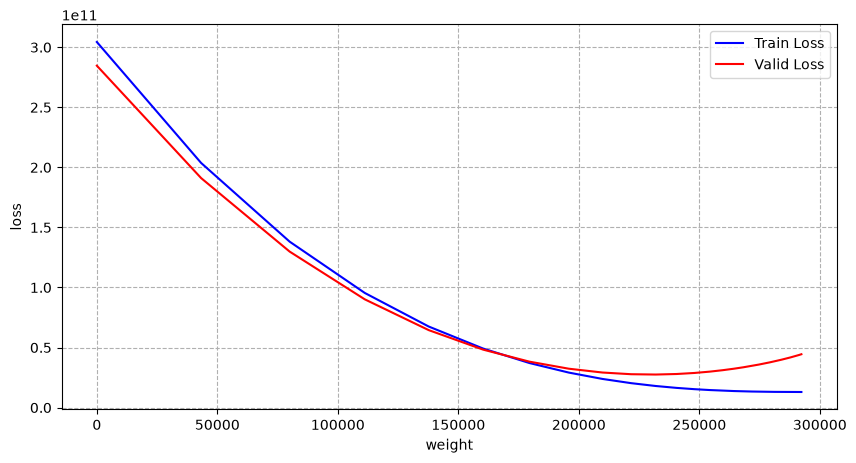

[weight=17500인 시점] = 과대적합(overfitting) 시작, 학습을 더 해도 향상되지 않고 Loss가 더 커질 수 있음
[Loss=3.0위 1e11] = 과소적합(underfitting), 학습이 덜 된 상태
==> 학습을 적절한 횟수로 시켜야 좋음 (더이상 Loss가 떨어지지 않을 때 학습을 종료 = Early Stopping)


In [19]:
plt.figure(figsize=(10, 5))

# 가중치와 loss 확인
plt.plot(history_w, train_losses, color='blue', label='Train Loss')
plt.plot(history_w, valid_losses, color='red', label='Valid Loss')
plt.xlabel('weight')
plt.ylabel('loss')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()
print("[weight=17500인 시점] = 과대적합(overfitting) 시작, 학습을 더 해도 향상되지 않고 Loss가 더 커질 수 있음")
print("[Loss=3.0위 1e11] = 과소적합(underfitting), 학습이 덜 된 상태")
print("==> 학습을 적절한 횟수로 시켜야 좋음 (더이상 Loss가 떨어지지 않을 때 학습을 종료 = Early Stopping)")

- 왼쪽: Underfitting(과소적합)
  - 가중치가 아직 충분히 학습되지 않은 상태
  - Train Loss와 Validation Loss가 모두 높다.

- 가운데: 적절한 학습 지점
  - Validation Loss가 가장 낮은 지점
  - 새로운 데이터에 대한 예측 성능이 가장 좋다.
  - 이 시점의 Weight를 최종 가중치로 선택한다.

- 오른쪽: Overfitting(과적합)
  - Train Loss는 계속 감소한다.
  - 그러나 Validation Loss는 다시 증가한다.
  - 훈련 데이터에만 지나치게 맞춘 상태이다.

Validation Loss 최저 Epoch
→ 최적 Epoch
→ 해당 시점의 모델 가중치 저장
→ 이후 Validation Loss가 상승하면 과적합

In [23]:
weight = 0.0
bias = 0.0
learning_rate = 0.1
epochs = 20  # Validation Loss가 거의 수렴하는 지점까지 학습

train_losses = []
valid_losses = []
history_w = []

N_train = len(X_train)

# 경사하강법 루프
for epoch in range(epochs):
    # 1. 훈련 세트 예측 및 Loss 계산
    y_pred_train = weight * X_train + bias
    train_loss = np.mean((y_pred_train - y_train) ** 2)
    train_losses.append(train_loss)

    # 2. 훈련 세트로만 기울기 계산 및 가중치 업데이트
    dw = (2 / N_train) * np.sum((y_pred_train - y_train) * X_train)
    db = (2 / N_train) * np.sum(y_pred_train - y_train)

    weight -= learning_rate * dw
    bias -= learning_rate * db

    # 3. 검증 세트는 가중치 업데이트 없이 성능만 확인
    y_pred_valid = weight * X_valid + bias
    valid_loss = np.mean((y_pred_valid - y_valid) ** 2)
    valid_losses.append(valid_loss)

    history_w.append(weight)


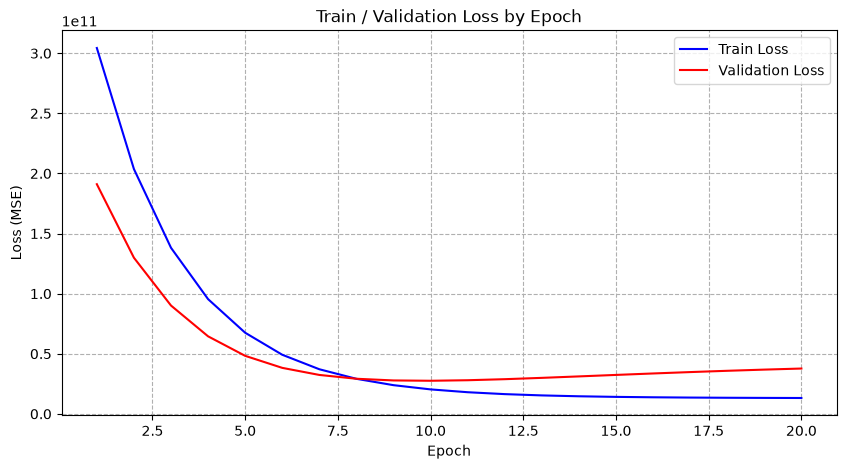

In [21]:
# Epoch별 Loss 그래프
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_losses, color="blue", label="Train Loss")
plt.plot(epochs_range, valid_losses, color="red", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Train / Validation Loss by Epoch")
plt.legend()
plt.grid(True, linestyle="--")
plt.show()


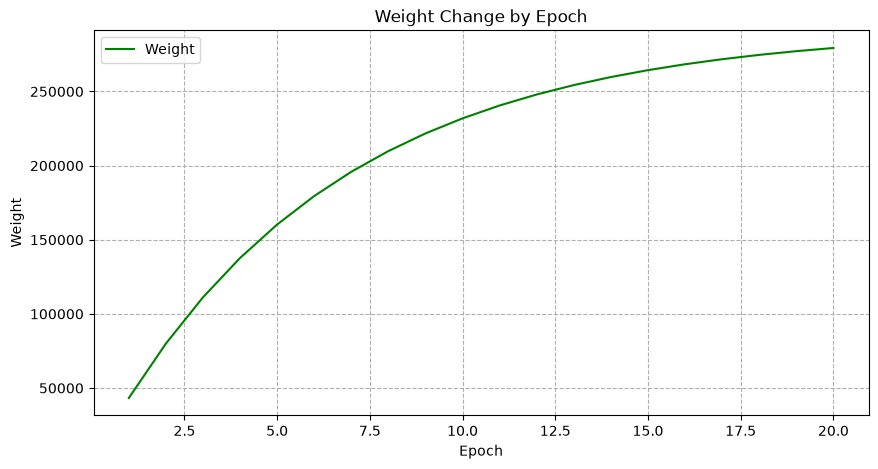

Validation Loss가 약 15~20 Epoch에서 거의 수렴합니다.
가중치도 약 20 Epoch 이후 변화가 매우 작습니다.
따라서 성능 차이가 미미하다면 epochs = 20을 선택할 수 있습니다.


In [ ]:
# Epoch별 가중치 변화 그래프
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, history_w, color="green", label="Weight")
plt.xlabel("Epoch")
plt.ylabel("Weight")
plt.title("Weight Change by Epoch")
plt.legend()
plt.grid(True, linestyle="--")
plt.show()

#Train Loss(파랑): 계속 감소 → 훈련 데이터에는 계속 더 잘 맞음
#Validation Loss(빨강): Epoch 8까지 감소 → 일반화 성능 향상
#Validation Loss: Epoch 9부터 증가 → 과적합 시작